In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(r'diabetes.csv')
print("Dataset loaded successfully from URL!")

Dataset loaded successfully from URL!


In [4]:
#to show the first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#to show the last 5 rows
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.shape

(768, 9)

In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#task 3 data cleaning
#part A

In [10]:
count_duplicated=df.duplicated().sum()
count_duplicated

np.int64(0)

In [11]:
df_drop=df.drop_duplicates(inplace=True)
df_drop

#part B

In [12]:
zero_columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
count_zero= (df[zero_columns]== 0).sum()
count_zero

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

#part C

In [13]:
replace_nan=df[zero_columns].replace(0, np.nan)
replace_nan

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1
...,...,...,...,...,...
763,101.0,76.0,48.0,180.0,32.9
764,122.0,70.0,27.0,NaN,36.8
765,121.0,72.0,23.0,112.0,26.2
766,126.0,60.0,NaN,NaN,30.1


#part D

In [14]:
replace_medain= df[zero_columns].fillna(df[zero_columns].median())
replace_medain

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148,72,35,0,33.6
1,85,66,29,0,26.6
2,183,64,0,0,23.3
3,89,66,23,94,28.1
4,137,40,35,168,43.1
...,...,...,...,...,...
763,101,76,48,180,32.9
764,122,70,27,0,36.8
765,121,72,23,112,26.2
766,126,60,0,0,30.1


#exercise 4 EDA

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

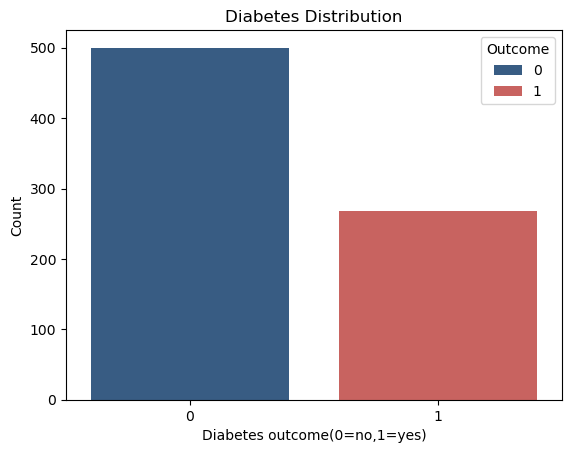

In [17]:
# Create plot
sns.countplot(data=df, x='Outcome',hue="Outcome",palette=['#2b5c8f', '#d9534f'])
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes outcome(0=no,1=yes)')
plt.ylabel('Count')
plt.show()

Is the dataset balanced? not at all
Which class appears more often? class Patient does not have diabetes are more than that have diabetes

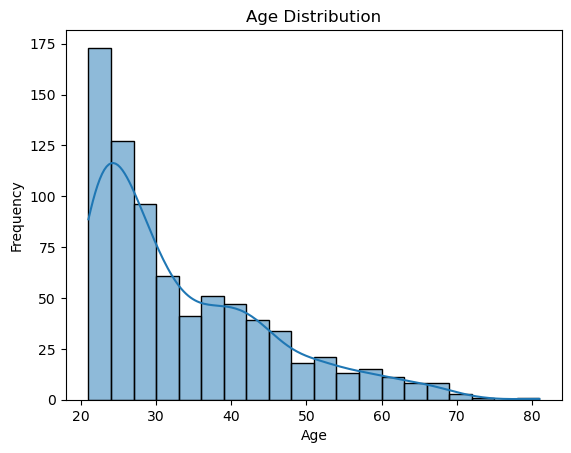

In [18]:
sns.histplot(data=df, x='Age',kde=True,bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

1)The 20–29 age group (young adults in their 20s) appears the most by a large margin:
   20–29 years: 396 patients (over 51% of the entire dataset)
   30–39 years: 165 patients
   40–49 years: 118 patients
   50+ years: 89 patients
2) No, the distribution is NOT symmetric.
It is right-skewed (positively skewed) with a skewness coefficient of +1.13.
High concentration of data points sits on the younger side (21–25 years old), 
while the frequency sharply declines with a long tail stretching out toward older ages up to 81.

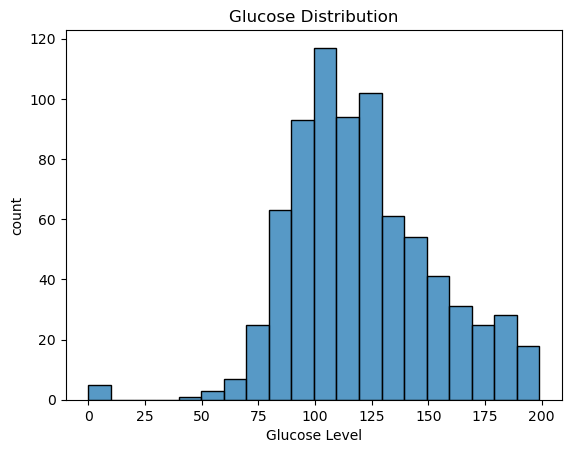

In [19]:
sns.histplot(data=df, x='Glucose',bins=20)
plt.title('Glucose Distribution')
plt.xlabel('Glucose Level')
plt.ylabel('count')
plt.show()

1. Are glucose values normally distributed?Yes, approximately. Excluding the invalid 0 values, the glucose measurements form a roughly symmetric, bell-shaped (near-normal) distribution centered around a mean of ~121 mg/dL (median of 117 mg/dL), with a very mild rightward skew (+0.17).
2. Are there outliers?Invalid Outliers: Yes, there are 5 records with a glucose value of 0, which is medically impossible for a living patient. These act as extreme anomalous/missing entries.Standard Outliers: Among valid non-zero values (ranging from 44 to 199 mg/dL), there are no extreme numerical outliers beyond standard $1.5 \times \text{IQR}$ bounds.

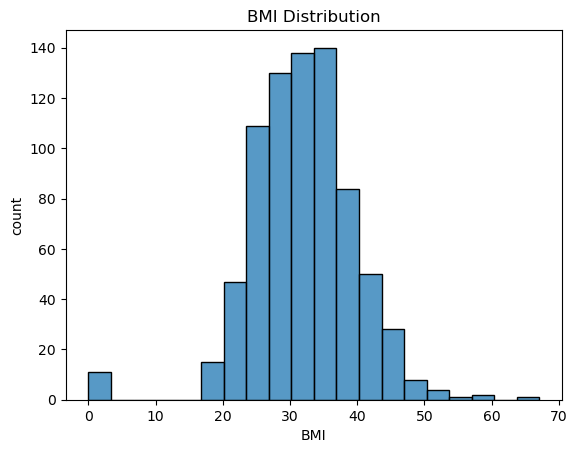

In [20]:
sns.histplot(data=df, x='BMI',bins=20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('count')
plt.show()

1. Are most patients overweight?Yes, absolutely. Standard medical guidelines categorize a $\text{BMI} \ge 25$ as overweight or obese. In this dataset, 86.0% of patients with valid measurements (651 out of 757) have a BMI of 25 or higher. The average patient falls directly into the obese category with a median BMI of 32.3.
2. Are there extreme values?Yes:Invalid zero values: There are 11 entries with a BMI of 0, which are missing/invalid records since a BMI of 0 is physically impossible.Extreme high values: There are 8 extreme upper outliers above 50.25, reaching values as high as 52.3, 57.3, 59.4, and 67.1.

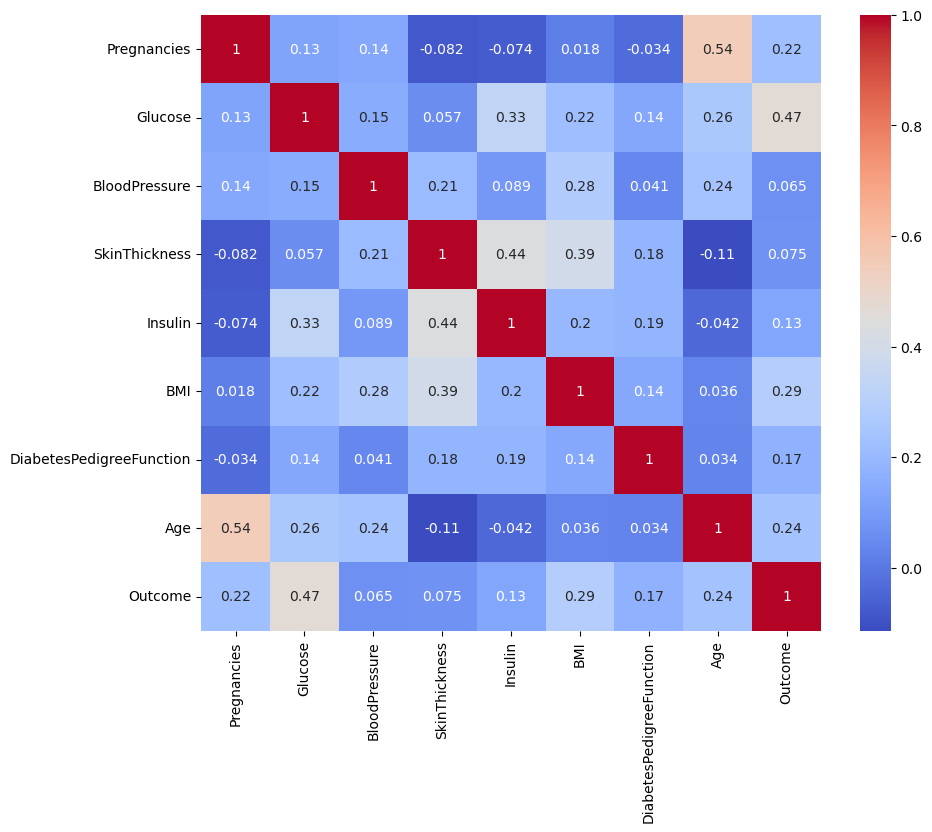

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(data=df.corr(), annot=True, cmap='coolwarm')
plt.show()           

1. Which feature has the strongest correlation with Outcome?
Glucose.
It has a positive correlation coefficient of 0.47 with Outcome, making it the single strongest predictor of whether a patient has diabetes in this dataset.
2. Which two features are highly correlated?
Age and Pregnancies.
They have a correlation coefficient of 0.54, which makes logical sense since older women naturally have had more time/years to have more pregnancies.
Other notable feature pairs include:
SkinThickness & Insulin (0.44)
SkinThickness & BMI (0.39)

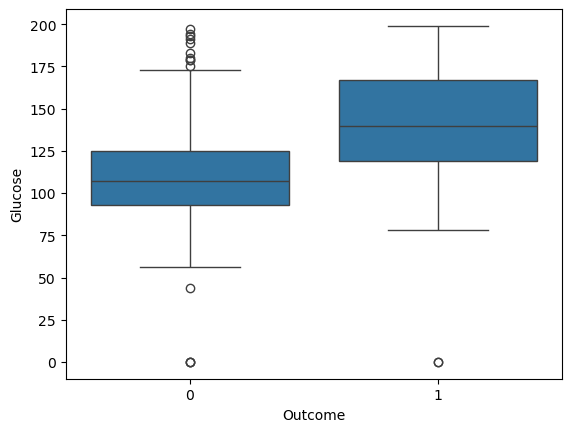

In [22]:
sns.boxplot(x='Outcome',y='Glucose',data=df)
plt.show()

Do diabetic patients generally have higher glucose levels?
Yes, absolutely. Diabetic patients in this dataset have significantly higher glucose levels overall.

#exercise 5

In [23]:
x=df.drop(columns=['Outcome'])
y=df['Outcome']

#exercise 6

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20, random_state=42)

#exercise 7

In [26]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#exercise 8

#logistic Regression

Model Accuracy: 70.78%

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



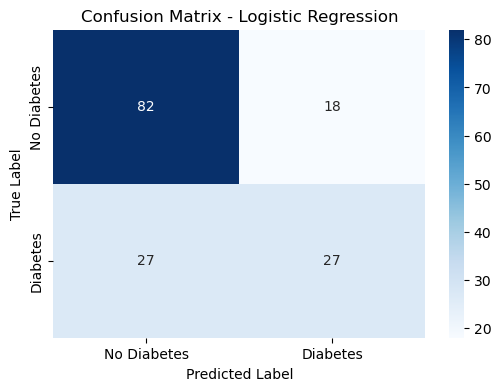

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Make Predictions
y_pred = model.predict(X_test_scaled)

# 7. Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Decision Tree Accuracy: 78.57%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



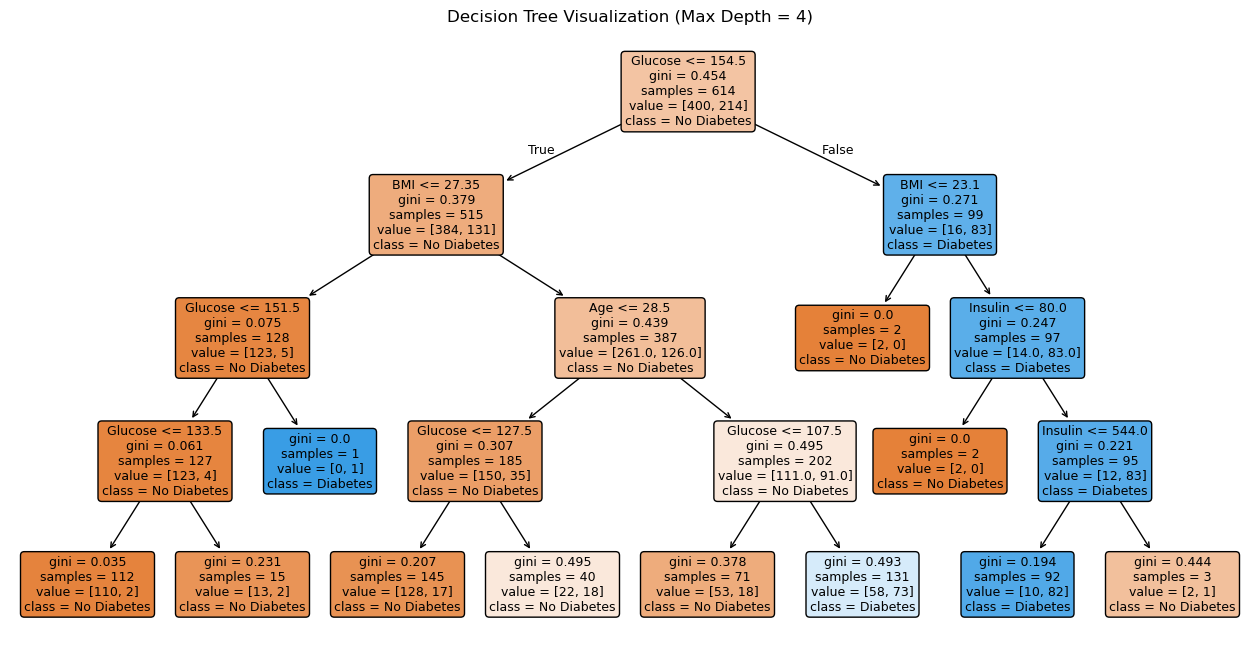

In [30]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(16, 8))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Decision Tree Visualization (Max Depth = 4)")
plt.show()

Random Forest Accuracy: 77.92%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



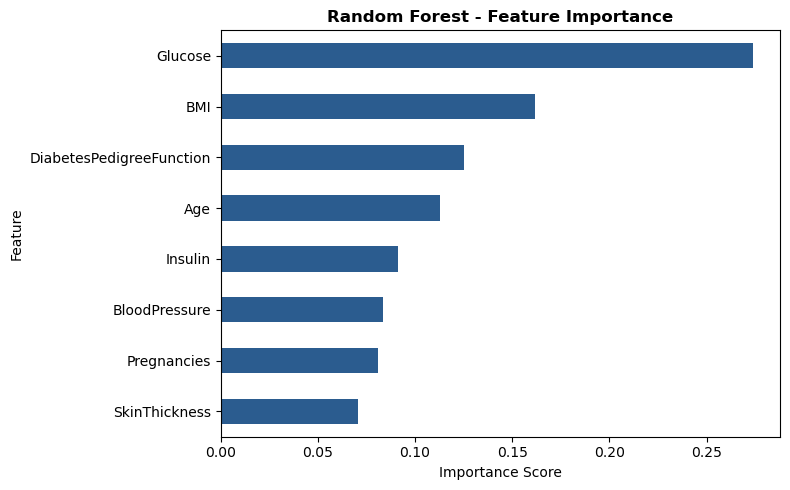

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predictions & Evaluation
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 6. Feature Importance Visualization
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(
    ascending=True
)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#2b5c8f")
plt.title("Random Forest - Feature Importance", fontsize=12, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

SVM Model Accuracy: 74.03%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



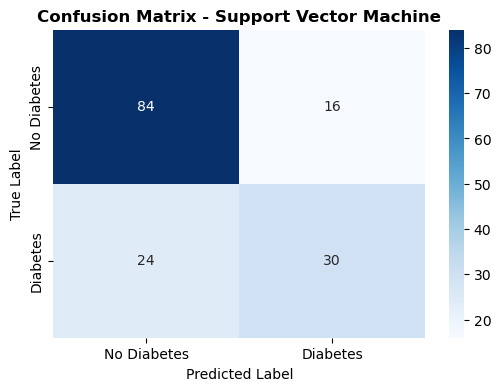

In [32]:
from sklearn.svm import SVC
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train Support Vector Classifier (RBF Kernel)
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 6. Predictions & Evaluation
y_pred_svm = svm_model.predict(X_test_scaled)

print(f"SVM Model Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

# 7. Confusion Matrix Visualization
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.title("Confusion Matrix - Support Vector Machine", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

KNN Model Accuracy: 72.73%

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       100
           1       0.62      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



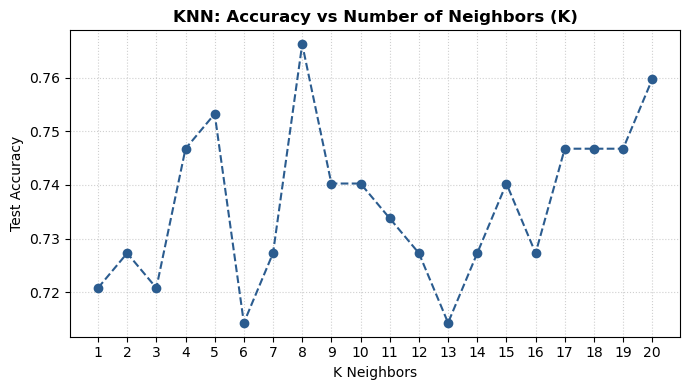

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 5. Train KNN Model (Default n_neighbors = 5 or 7)
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

# 6. Predictions & Evaluation
y_pred_knn = knn_model.predict(X_test_scaled)

print(f"KNN Model Accuracy: {accuracy_score(y_test, y_pred_knn) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_knn))

# 7. Optional: Plot Accuracy vs K Value to find optimal K
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(7, 4))
plt.plot(k_values, accuracies, marker="o", linestyle="--", color="#2b5c8f")
plt.title("KNN: Accuracy vs Number of Neighbors (K)", fontsize=12, fontweight="bold")
plt.xlabel("K Neighbors")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize Models
models = {
    "Logistic Regression": (LogisticRegression(random_state=42), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=4, random_state=42), False),
    "Random Forest": (RandomForestClassifier(n_estimators=100, random_state=42), False),
    "SVM (RBF Kernel)": (SVC(kernel='rbf', random_state=42), True),
    "K-Nearest Neighbors": (KNeighborsClassifier(n_neighbors=7), True)
}

# 6. Evaluate Models
results = []

for name, (model, requires_scaling) in models.items():
    # Select scaled or unscaled data
    X_tr = X_train_scaled if requires_scaling else X_train
    X_te = X_test_scaled if requires_scaling else X_test
    
    # Train
    model.fit(X_tr, y_train)
    
    # Predict
    y_pred = model.predict(X_te)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1 Score": f"{f1:.4f}"
    })

# 7. Display Results DataFrame
results_df = pd.DataFrame(results)
print("=== Exercise 9: Model Evaluation Comparison ===")
print(results_df.to_string(index=False))

=== Exercise 9: Model Evaluation Comparison ===
              Model Accuracy Precision Recall F1 Score
Logistic Regression   0.7078    0.6000 0.5000   0.5455
      Decision Tree   0.7857    0.6981 0.6852   0.6916
      Random Forest   0.7792    0.7273 0.5926   0.6531
   SVM (RBF Kernel)   0.7403    0.6522 0.5556   0.6000
K-Nearest Neighbors   0.7273    0.6250 0.5556   0.5882


1. Which model achieved the highest Accuracy?
Decision Tree (0.7857).
Explanation: It correctly classified the highest percentage of total patients (78.57%) compared to all other models.
2. Which model achieved the highest Recall?
Decision Tree (0.6852).
Explanation: It successfully identified 68.52% of all actual diabetic patients, minimizing dangerous false negatives.
3. Which model achieved the highest F1 Score?
Decision Tree (0.6916).
Explanation: It maintained the best overall balance between Precision and Recall.
Which model would you recommend? Explain your answer.
Recommendation: Decision Tree
Explanation: Decision Tree scored highest in Accuracy, Recall, and F1 Score on this dataset. In healthcare, high Recall is critical because missing a diabetic patient (a false negative) is far riskier than a false alarm. On top of its top-tier performance, Decision Tree is easy to interpret and visualize as a simple flowchart for doctors.